<a href="https://colab.research.google.com/github/sarveshrastogi1/Meibomian-Gland/blob/main/meibo_extract_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

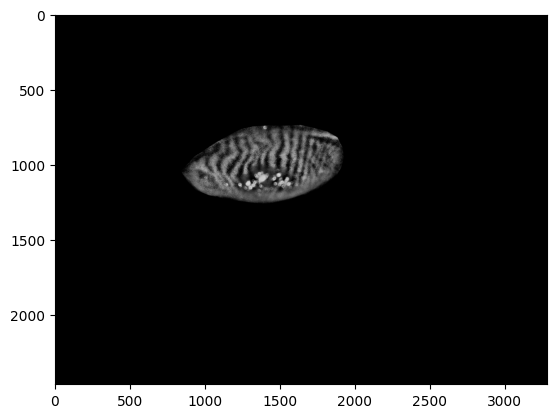

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('/content/1e0bcf71_1683183650536_1683183650536_33_M_1683183993462_r_le_0_Upper_lid_Meibography.png')

plt.imshow(img)

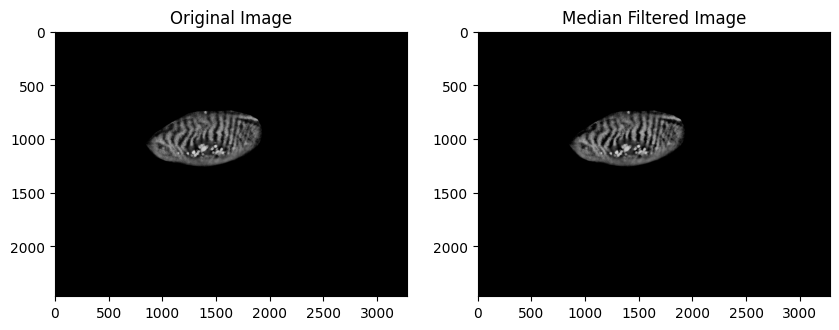

In [ ]:
# prompt: apply median filter to the img

# Apply median filter
median_filtered_img = cv2.medianBlur(img, 5)  # 5 is the kernel size, you can adjust it

# Display the original and filtered images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(median_filtered_img)
plt.title('Median Filtered Image')
plt.show()

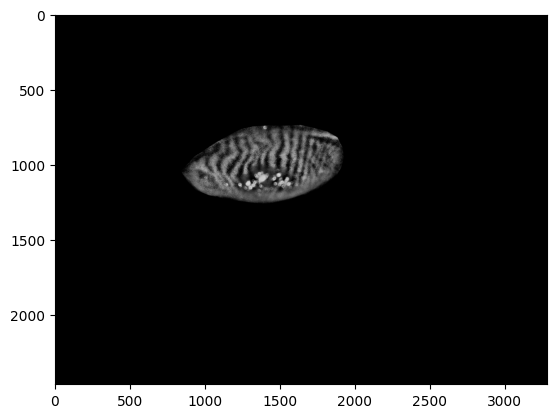

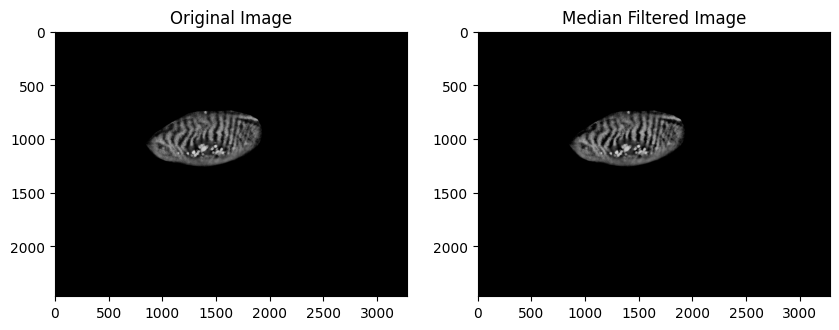

In [ ]:
# prompt: save median filtered image

import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('/content/1e0bcf71_1683183650536_1683183650536_33_M_1683183993462_r_le_0_Upper_lid_Meibography.png')

plt.imshow(img)

# Apply median filter
median_filtered_img = cv2.medianBlur(img, 5)  # 5 is the kernel size, you can adjust it

# Save the median filtered image
cv2.imwrite('median_filtered_image.png', median_filtered_img)

# Display the original and filtered images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(median_filtered_img)
plt.title('Median Filtered Image')
plt.show()

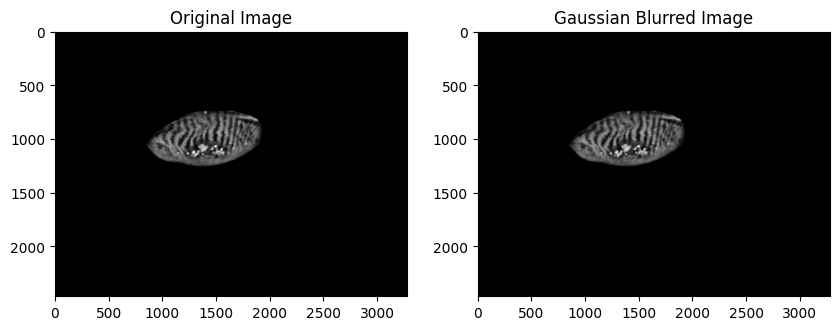

In [ ]:
# prompt: apply local gaussian filter on the initial image and save it

import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('/content/1e0bcf71_1683183650536_1683183650536_33_M_1683183993462_r_le_0_Upper_lid_Meibography.png')

# Apply Gaussian blur
blurred_img = cv2.GaussianBlur(img, (5, 5), 0)  # (5, 5) is the kernel size, 0 is the standard deviation

# Save the blurred image
cv2.imwrite('gaussian_blurred_image.png', blurred_img)

# Display the original and blurred images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(blurred_img)
plt.title('Gaussian Blurred Image')
plt.show()

In [ ]:
import cv2
import numpy as np

def apply_kernel(image, kernel_size=7):
    # Ensure the kernel size is odd for symmetry
    assert kernel_size % 2 == 1, "Kernel size must be odd."

    # Load the image in grayscale
    img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    output = img.copy()

    # Calculate the threshold for 75% non-zero pixels
    threshold = kernel_size * kernel_size * 0.60

    # Get the dimensions of the image
    height, width = img.shape

    # Apply the kernel sliding through the image
    for y in range(height - kernel_size + 1):
        for x in range(width - kernel_size + 1):
            # Extract the current kernel region
            kernel_region = img[y:y + kernel_size, x:x + kernel_size]

            # Check if 75% or more of the pixels are non-zero
            if np.count_nonzero(kernel_region) >= threshold:
                # Set the entire kernel region to white in the output image
                output[y:y + kernel_size, x:x + kernel_size] = 255

    return output

# Usage
input_image = '/content/1e0bcf71_1683183650536_1683183650536_33_M_1683183993462_r_le_0_Upper_lid_Meibography.png'  # Replace with the path to your image
output_image = 'output_image.jpg'
kernel_size = 3  # You can change the kernel size

# Process the image
result = apply_kernel(input_image, kernel_size)

# Save the output image
cv2.imwrite(output_image, result)

print("Processing complete. Output saved as", output_image)



Processing complete. Output saved as output_image_60_7.jpg


In [ ]:
import cv2
image = cv2.imread('/content/images/1e0bcf71_1686897642110_1686897642110_24_F_1686897894251_r_le_32.5_Lower_lid_Meibography.png')

print(max(image.flatten()))
print(min(image.flatten()))
print(image.shape)

250
0
(463, 1099, 3)


In [ ]:
# prompt: for the folder of images, take each image and keep only keep the pixels that are 255, make the rest as zero. replace each image with this new image in the same folder

import cv2
import os

def process_images_in_folder(folder_path):
  for filename in os.listdir(folder_path):
    if filename.endswith(('.png', '.jpg', '.jpeg')):  # Add more image extensions if needed
      image_path = os.path.join(folder_path, filename)
      try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
          print(f"Could not read image: {image_path}")
          continue

        # Keep only pixels with value 255, set the rest to 0
        img[img < 200] = 0

        # Save the modified image, overwriting the original
        cv2.imwrite(image_path, img)
        print(f"Processed and saved: {filename}")

      except Exception as e:
        print(f"Error processing {filename}: {e}")

# Example usage: replace '/content/your_image_folder' with the actual path
process_images_in_folder('/content/images')

Processed and saved: 1e0bcf71_1687002189068_1687002189068_43_M_1687002478993_r_le_23.75_Upper_lid_Meibography.png
Processed and saved: 1e0bcf71_1687252040532_1687252040532_28_M_1687252165941_r_re_7.5_Lower_lid_Meibography.png
Processed and saved: 1e0bcf71_1687254554894_1687254554894_22_F_1687254711831_r_re_0_Upper_lid_Meibography.png
Processed and saved: 1e0bcf71_1687252040532_1687252040532_28_M_1687252288448_r_re_7.5_Upper_lid_Meibography.png
Processed and saved: 1e0bcf71_1686896795500_1686896795500_24_F_1686897050680_r_le_22.5_Upper_lid_Meibography.png
Processed and saved: 1e0bcf71_1687253417435_1687253417435_27_F_1687253601991_r_re_15_Upper_lid_Meibography.png
Processed and saved: 1e0bcf71_1687254554894_1687254554894_22_F_1687254764993_r_le_0_Upper_lid_Meibography.png
Processed and saved: 1e0bcf71_1686897642110_1686897642110_24_F_1686897942950_r_le_32.5_Upper_lid_Meibography.png
Processed and saved: 1e0bcf71_1687254554894_1687254554894_22_F_1687254623386_r_re_0_Lower_lid_Meibography

Processing complete. Output saved as output_image_50_7.jpg


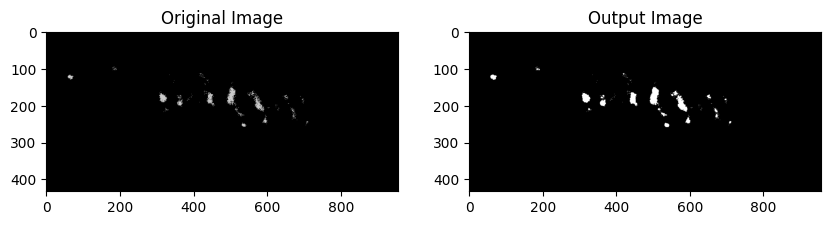

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def apply_kernel(image, kernel_size=6):
    # Ensure the kernel size is odd for symmetry
    assert kernel_size % 2 == 1, "Kernel size must be odd."

    # Load the image in grayscale
    img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    output = img.copy()

    # Calculate the threshold for 75% non-zero pixels
    threshold = kernel_size * kernel_size * 0.50

    # Get the dimensions of the image
    height, width = img.shape

    # Apply the kernel sliding through the image
    for y in range(height - kernel_size + 1):
        for x in range(width - kernel_size + 1):
            # Extract the current kernel region
            kernel_region = img[y:y + kernel_size, x:x + kernel_size]

            # Check if 75% or more of the pixels are non-zero
            if np.count_nonzero(kernel_region) >= threshold:
                # Set the entire kernel region to white in the output image
                output[y:y + kernel_size, x:x + kernel_size] = 255

    return output

# Usage
input_image = '/content/images/1e0bcf71_1687252040532_1687252040532_28_M_1687252288448_r_re_7.5_Upper_lid_Meibography.png'  # Replace with the path to your image
output_image_50_7 = 'output_image_50_7.jpg'
kernel_size = 3  # You can change the kernel size
img=cv2.imread(input_image)
# Process the image
result = apply_kernel(input_image, kernel_size)

# Save the output image
cv2.imwrite(output_image_50_7, result)

print("Processing complete. Output saved as", output_image_50_7)

# Display the original and processed images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title('Output Image')
plt.show()


Processing complete. Output saved as output_image_remove_50_7.jpg


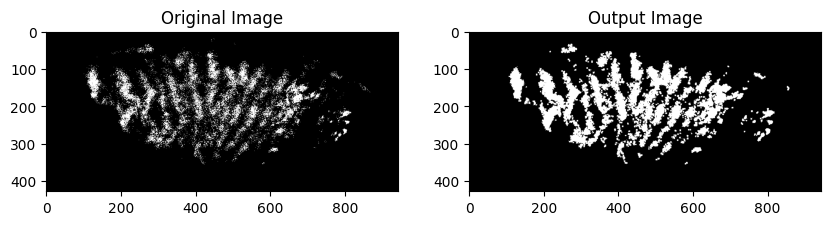

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def remove_objects_by_size(image, min_size=10, max_size=float('inf')):
    """Removes objects from an image based on their size.

    Args:
        image: The input image (grayscale or binary).
        min_size: The minimum size (in pixels) of objects to keep.
        max_size: The maximum size (in pixels) of objects to keep.
                  Defaults to infinity, meaning no upper limit.

    Returns:
        The image with objects outside the specified size range removed.
    """

    # Perform connected components analysis
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(image, connectivity=8)

    # Create an empty mask to store the objects to keep
    mask = np.zeros_like(image)

    # Filter objects based on size
    for i in range(1, num_labels):  # Skip label 0 (background)
        size = stats[i, cv2.CC_STAT_AREA]
        if min_size <= size <= max_size:
            mask[labels == i] = 255

    return mask

def apply_kernel(image, kernel_size=7):
    # Ensure the kernel size is odd for symmetry
    assert kernel_size % 2 == 1, "Kernel size must be odd."

    # Create an output copy of the image
    output = image.copy()

    # Calculate the threshold for 50% non-zero pixels
    threshold = kernel_size * kernel_size * 0.40

    # Get the dimensions of the image
    height, width = image.shape

    # Apply the kernel sliding through the image
    for y in range(height - kernel_size + 1):
        for x in range(width - kernel_size + 1):
            # Extract the current kernel region
            kernel_region = image[y:y + kernel_size, x:x + kernel_size]

            # Check if 50% or more of the pixels are non-zero
            if np.count_nonzero(kernel_region) >= threshold:
                # Set the entire kernel region to white in the output image
                output[y:y + kernel_size, x:x + kernel_size] = 255

    # Apply morphological opening to remove small dots (optional step)
    output = remove_objects_by_size(output)

    return output

# Usage
input_image = '/content/images/1e0bcf71_1687257599432_1687257599432_28_F_1687257811430_r_le_3.75_Upper_lid_Meibography.png'  # Replace with your image path
output_image = 'output_image_remove_50_7.jpg'
kernel_size = 3  # Change the kernel size if needed

# Load the image in grayscale
img = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)

# Check if the image was successfully loaded
if img is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Remove small dots and apply kernel-based processing
    result = apply_kernel(img, kernel_size)

    # Save the output image
    cv2.imwrite(output_image, result)

    print("Processing complete. Output saved as", output_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title('Output Image')
plt.show()


Closing operation applied. Output saved as closed_image.png


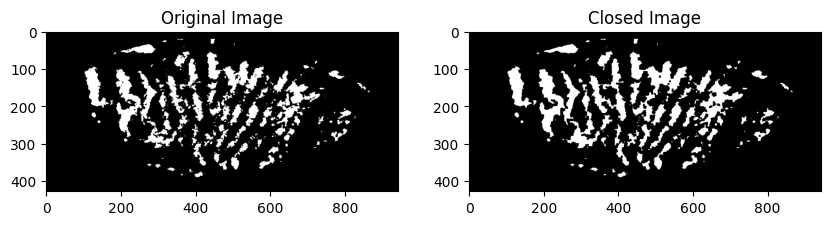

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt  # Importing matplotlib for displaying images

def apply_closing(image_path, kernel_size=20, output_path='closed_image.png'):
    """
    Applies a closing morphological operation on an image.

    Args:
        image_path (str): Path to the input image.
        kernel_size (int): Size of the kernel to use for the operation. Default is 5.
        output_path (str): Path to save the output image. Default is 'closed_image.png'.

    Returns:
        None
    """
    # Load the image in grayscale mode
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was successfully loaded
    if image is None:
        print(f"Error: Could not load the image. Please check the file path: {image_path}")
        return

    # Create a kernel for the morphological operation
    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    # Apply the closing operation
    closed_image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

    # Save the result
    cv2.imwrite(output_path, closed_image)
    print(f"Closing operation applied. Output saved as {output_path}")

# Usage example
input_image_path = '/content/median_filtered_image (1).png'  # Replace with your image path
output_image_path = 'closed_image.png'
kernel_size = 5  # Adjust the kernel size as needed

apply_closing(input_image_path, kernel_size, output_image_path)

# Load the images to display
image = cv2.imread(input_image_path, cv2.IMREAD_GRAYSCALE)
closed_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the images were loaded correctly
if image is None:
    print(f"Error: Could not load the original image. Please check the file path: {input_image_path}")
elif closed_image is None:
    print(f"Error: Could not load the closed image. Please check the file path: {output_image_path}")
else:
    # Display the images using matplotlib
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    plt.imshow(closed_image, cmap='gray')
    plt.title('Closed Image')

    plt.show()


Small contours removed. Output saved as contour_image.png


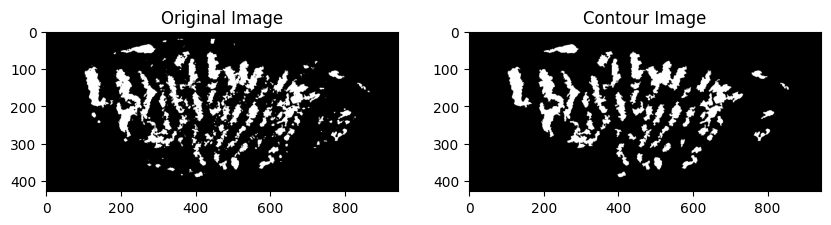

In [ ]:
import cv2
import numpy as np

def remove_small_contours(image_path, min_contour_area, output_path='output_image.png'):
    """
    Removes contours from an image that are smaller than the specified size.

    Args:
        image_path (str): Path to the input image.
        min_contour_area (int): Minimum contour area to keep. Contours smaller than this will be removed.
        output_path (str): Path to save the output image. Default is 'output_image.png'.

    Returns:
        None
    """
    # Load the image in grayscale mode
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was successfully loaded
    if image is None:
        print("Error: Could not load the image. Please check the file path.")
        return

    # Threshold the image to create a binary image
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

    # Find contours in the binary image
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create an empty mask to draw the contours we want to keep
    mask = np.zeros_like(image)

    # Filter and draw contours based on the minimum area
    for contour in contours:
        if cv2.contourArea(contour) >= min_contour_area:
            cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

    # Save the resulting image
    cv2.imwrite(output_path, mask)
    print(f"Small contours removed. Output saved as {output_path}")

# Usage example
input_image_path = '/content/median_filtered_image (1).png'  # Replace with your image path
output_image_path = 'contour_image.png'
min_contour_area = 100  # Set the minimum contour area to keep

remove_small_contours(input_image_path, min_contour_area, output_image_path)

image=cv2.imread(input_image_path,cv2.IMREAD_GRAYSCALE)
mask=cv2.imread(output_image_path)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Contour Image')
plt.show()


Morphological opening applied and small contours removed. Output saved as morph_opened_contour_image.png


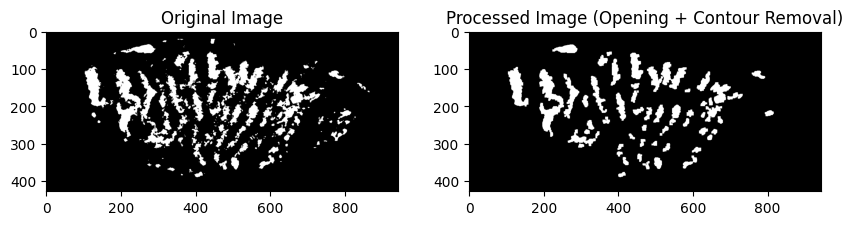

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_morphological_opening_and_remove_small_contours(image_path, min_contour_area, output_path='output_image.png'):
    """
    Applies morphological opening to separate connected objects, followed by the removal of small contours.

    Args:
        image_path (str): Path to the input image.
        min_contour_area (int): Minimum contour area to keep. Contours smaller than this will be removed.
        output_path (str): Path to save the output image. Default is 'output_image.png'.

    Returns:
        None
    """
    # Load the image in grayscale mode
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was successfully loaded
    if image is None:
        print("Error: Could not load the image. Please check the file path.")
        return

    # Threshold the image to create a binary image
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

    # Apply morphological opening (erosion followed by dilation) to separate connected objects
    kernel = np.ones((3, 3), np.uint8)
    morph_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Find contours in the opened image
    contours, _ = cv2.findContours(morph_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create an empty mask to draw the contours we want to keep
    mask = np.zeros_like(image)

    # Filter and draw contours based on the minimum area
    for contour in contours:
        if cv2.contourArea(contour) >= min_contour_area:
            cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

    # Save the resulting image
    cv2.imwrite(output_path, mask)
    print(f"Morphological opening applied and small contours removed. Output saved as {output_path}")

# Usage example
input_image_path = '/content/median_filtered_image (1).png'  # Replace with your image path
output_image_path = 'morph_opened_contour_image.png'
min_contour_area = 100  # Set the minimum contour area to keep

apply_morphological_opening_and_remove_small_contours(input_image_path, min_contour_area, output_image_path)

# Visualization
image = cv2.imread(input_image_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Processed Image (Opening + Contour Removal)')
plt.show()


Opening, erosion applied and small contours removed. Output saved as opened_eroded_contour_image.png


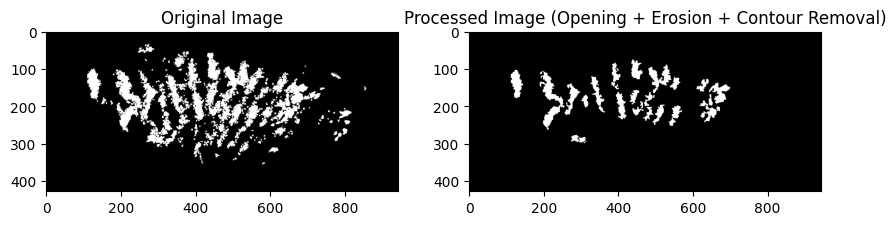

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_opening_erosion_and_remove_small_contours(image_path, min_contour_area, output_path='output_image.png'):
    """
    Applies morphological opening to separate connected objects, followed by erosion and removal of small contours.

    Args:
        image_path (str): Path to the input image.
        min_contour_area (int): Minimum contour area to keep. Contours smaller than this will be removed.
        output_path (str): Path to save the output image. Default is 'output_image.png'.

    Returns:
        None
    """
    # Load the image in grayscale mode
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was successfully loaded
    if image is None:
        print("Error: Could not load the image. Please check the file path.")
        return

    # Threshold the image to create a binary image
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

    # Apply morphological opening (erosion followed by dilation) to separate connected objects
    kernel = np.ones((3, 3), np.uint8)
    morph_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Apply erosion to further shrink the objects
    eroded = cv2.erode(morph_opened, kernel, iterations=1)

    # Find contours in the eroded image
    contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create an empty mask to draw the contours we want to keep
    mask = np.zeros_like(image)

    # Filter and draw contours based on the minimum area
    for contour in contours:
        if cv2.contourArea(contour) >= min_contour_area:
            cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

    # Save the resulting image
    cv2.imwrite(output_path, mask)
    print(f"Opening, erosion applied and small contours removed. Output saved as {output_path}")

# Usage example
input_image_path = '/content/output_image_remove_50_7.jpg'  # Replace with your image path
output_image_path = 'opened_eroded_contour_image.png'
min_contour_area = 300  # Set the minimum contour area to keep

apply_opening_erosion_and_remove_small_contours(input_image_path, min_contour_area, output_image_path)

# Visualization
image = cv2.imread(input_image_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Processed Image (Opening + Erosion + Contour Removal)')
plt.show()


Contours separated and small contours removed. Output saved as contour_separated_image.png


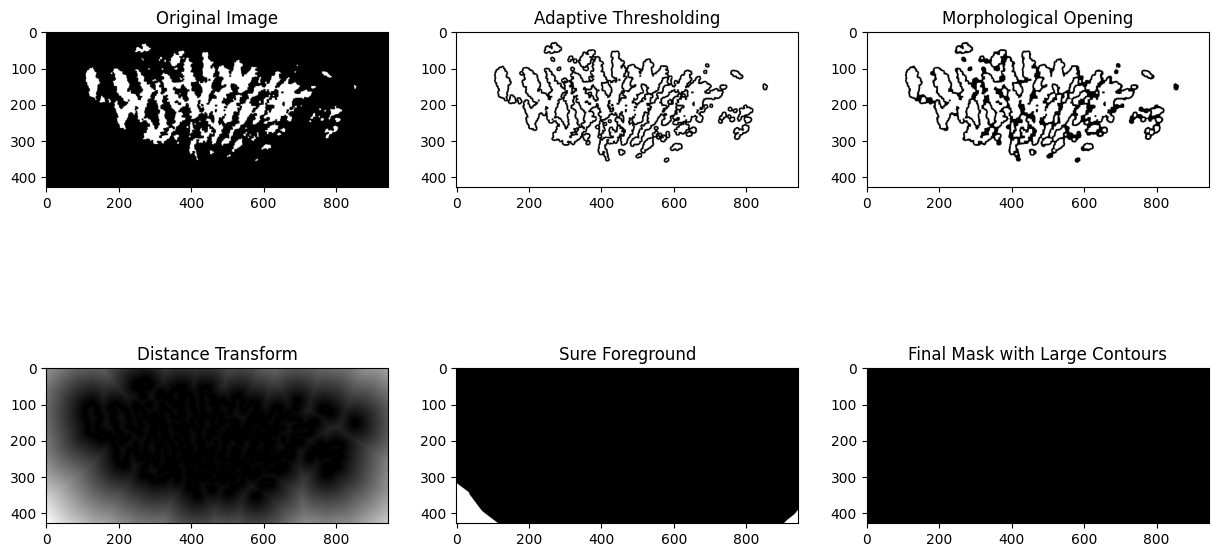

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def separate_and_remove_small_contours(image_path, min_contour_area, output_path='output_image.png'):
    """
    Removes small contours and separates merged ones using morphological operations and distance transform.
    """

    # Load the image in grayscale mode
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was successfully loaded
    if image is None:
        print(f"Error: Could not load the image at {image_path}.")
        return

    # Adaptive thresholding instead of fixed threshold
    binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    # Apply morphological opening to remove noise
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background area
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # Finding sure foreground area using distance transform
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

    # Finding unknown region (subtract sure foreground from background)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Marker labelling
    _, markers = cv2.connectedComponents(sure_fg)

    # Add 1 to all labels so that the sure background is not 0
    markers = markers + 1
    markers[unknown == 255] = 0

    # Apply the watershed algorithm
    markers = cv2.watershed(cv2.cvtColor(image, cv2.COLOR_GRAY2BGR), markers)
    output = np.copy(image)
    output[markers == -1] = 255

    # Find contours after segmentation
    contours, _ = cv2.findContours(output, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create an empty mask to draw the contours we want to keep
    mask = np.zeros_like(image)

    # Filter and draw contours based on the minimum area
    for contour in contours:
        if cv2.contourArea(contour) >= min_contour_area:
            cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

    # Save the resulting image
    success = cv2.imwrite(output_path, mask)
    if success:
        print(f"Contours separated and small contours removed. Output saved as {output_path}")
    else:
        print(f"Error: Could not save the output image to {output_path}")

    # Debugging plots for intermediate steps
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')

    plt.subplot(2, 3, 2)
    plt.imshow(binary, cmap='gray')
    plt.title('Adaptive Thresholding')

    plt.subplot(2, 3, 3)
    plt.imshow(opening, cmap='gray')
    plt.title('Morphological Opening')

    plt.subplot(2, 3, 4)
    plt.imshow(dist_transform, cmap='gray')
    plt.title('Distance Transform')

    plt.subplot(2, 3, 5)
    plt.imshow(sure_fg, cmap='gray')
    plt.title('Sure Foreground')

    plt.subplot(2, 3, 6)
    plt.imshow(mask, cmap='gray')
    plt.title('Final Mask with Large Contours')

    plt.show()

# Usage example
input_image_path = '/content/closed_image.png'  # Replace with your image path
output_image_path = 'contour_separated_image.png'
min_contour_area = 300  # Set the minimum contour area to keep

separate_and_remove_small_contours(input_image_path, min_contour_area, output_image_path)


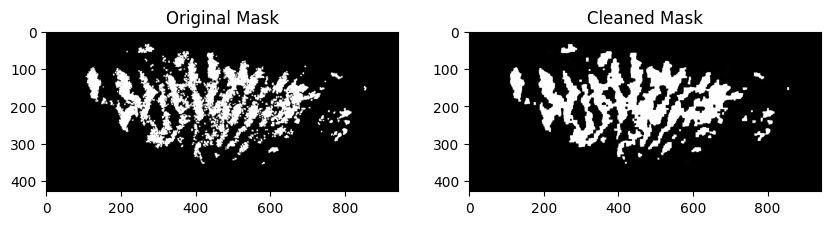

In [ ]:
import cv2
import numpy as np

# Read the binary mask
binary_mask = cv2.imread('/content/output_image_remove_50_7.jpg', 0)

# Define a kernel for morphological operations
kernel = np.ones((5, 5), np.uint8)

# Apply closing to fill holes
mask_cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

# Apply morphological opening to remove noise
mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)

# Apply morphological opening to remove noise
mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)

# Apply closing to fill holes
mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_CLOSE, kernel)

# Save or display the cleaned mask
cv2.imwrite('cleaned_mask.jpg', mask_cleaned)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(binary_mask, cmap='gray')
plt.title('Original Mask')

plt.subplot(1,2,2)
plt.imshow(mask_cleaned, cmap='gray')
plt.title('Cleaned Mask')
plt.show()



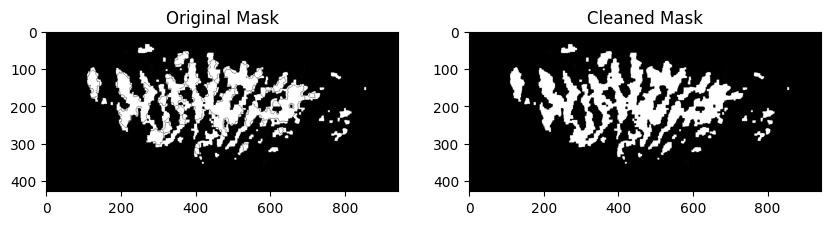

In [ ]:
import cv2
import numpy as np

# Load the binary mask image
binary_mask = cv2.imread('/content/cleaned_mask.jpg', 0)

# Step 1: Remove small noise using morphological opening
kernel = np.ones((3, 3), np.uint8)
mask_cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)

# Step 2: Apply dilation to get the sure background (more iterations for aggressive effect)
sure_bg = cv2.dilate(mask_cleaned, kernel, iterations=3)

# Step 3: Use distance transform to get the sure foreground
dist_transform = cv2.distanceTransform(mask_cleaned, cv2.DIST_L2, 5)

# Use a lower threshold (0.4 instead of 0.7) to get more aggressive foreground
ret, sure_fg = cv2.threshold(dist_transform, 0.4*dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Step 4: Subtract sure foreground from sure background to get unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Step 5: Label markers for watershed algorithm
ret, markers = cv2.connectedComponents(sure_fg)

# Add 1 to all labels to ensure the background is not 0
markers = markers + 1

# Mark the unknown region as 0 (this will be treated as the boundary by the watershed)
markers[unknown == 255] = 0

# Step 6: Convert original image to BGR (required by watershed)
original_bgr = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)

# Apply the watershed algorithm
markers = cv2.watershed(original_bgr, markers)

# Step 7: Mark the watershed boundaries on the mask (regions with label -1)
binary_mask[markers == -1] = 0

# Save or display the final result
cv2.imwrite('aggressive_watershed_result.jpg', binary_mask)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(binary_mask, cmap='gray')
plt.title('Original Mask')

plt.subplot(1,2,2)
plt.imshow(mask_cleaned, cmap='gray')
plt.title('Cleaned Mask')
plt.show()


Median filter applied. Output saved to median_filtered_image.png


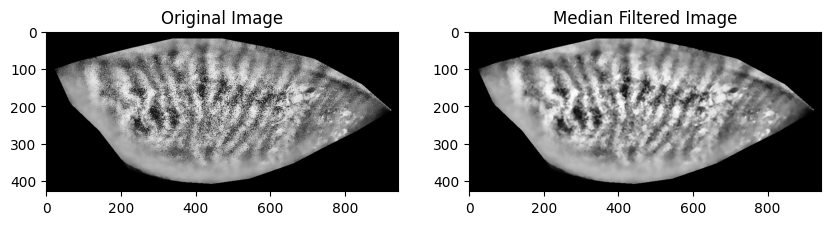

Median filter applied. Output saved to median_filtered_image.png


In [ ]:
# prompt: appply median filter on this :   /content/1e0bcf71_1687257599432_1687257599432_28_F_1687257811430_r_le_3.75_Upper_lid_Meibography.png

import cv2
import numpy as np
from matplotlib import pyplot as plt

def apply_median_filter(image_path, kernel_size=3, output_path='median_filtered_image.png'):
    """Applies a median filter to an image.

    Args:
        image_path: Path to the input image.
        kernel_size: Size of the kernel for the median filter (must be odd).
        output_path: Path to save the output image.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return

    median_filtered_img = cv2.medianBlur(img, kernel_size)
    cv2.imwrite(output_path, median_filtered_img)
    print(f"Median filter applied. Output saved to {output_path}")

    # Display the original and filtered images
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    plt.imshow(median_filtered_img, cmap='gray')
    plt.title('Median Filtered Image')
    plt.show()

    cv2.imwrite(output_path, median_filtered_img)
    print(f"Median filter applied. Output saved to {output_path}")



# Example usage
image_path = '/content/1e0bcf71_1687257599432_1687257599432_28_F_1687257811430_r_le_3.75_Upper_lid_Meibography.png'
apply_median_filter(image_path, kernel_size=5) # Adjust kernel_size as needed
